# Exploratory Data Analysis - Fitness & Calorie Dataset

This notebook performs EDA on the cleaned fitness dataset to understand distributions, relationships, and spot potential outliers.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional style for all plots
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Load the data
df = pd.read_csv('../data/data_cleaned.csv')

In [2]:
# Dataset info and basic statistics
print("=== DataFrame Info ===")
df.info()
print("\n=== Summary Statistics ===")
df.describe()

=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2185 entries, 0 to 2184
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           2185 non-null   object 
 1   workout_id        2185 non-null   object 
 2   exercise_order    2185 non-null   int64  
 3   age               2183 non-null   float64
 4   sex               2185 non-null   object 
 5   height_cm         2183 non-null   float64
 6   weight_kg         2185 non-null   int64  
 7   exercise_type     2185 non-null   object 
 8   duration_minutes  2183 non-null   float64
 9   intensity_level   2185 non-null   object 
 10  avg_heart_rate    2183 non-null   float64
 11  calories_burned   2185 non-null   int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 205.0+ KB

=== Summary Statistics ===


,exercise_order,age,height_cm,weight_kg,duration_minutes,avg_heart_rate,calories_burned
count,2185.000000,2183.000000,2183.000000,2185.000000,2183.000000,2183.000000,2185.000000
mean,1.791304,35.487861,173.246908,76.354233,33.814934,127.017407,251.307094
std,0.772357,10.377818,9.372129,12.813358,17.237773,25.597707,164.241239
min,1.000000,19.000000,150.000000,50.000000,5.000000,88.000000,30.000000
25%,1.000000,27.000000,165.000000,67.000000,20.000000,105.000000,120.000000
50%,2.000000,34.000000,175.000000,76.000000,35.000000,125.000000,210.000000
75%,2.000000,44.000000,181.000000,86.000000,45.000000,138.000000,350.000000
max,4.000000,63.000000,195.000000,192.000000,90.000000,178.000000,810.000000


In [3]:
# Check for missing values (NaN)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
if missing.sum() > 0:
    display(missing_df[missing_df['Missing Count'] > 0])
else:
    print("No missing values found.")

,Missing Count,Missing %
age,2,0.09
height_cm,2,0.09
duration_minutes,2,0.09
avg_heart_rate,2,0.09


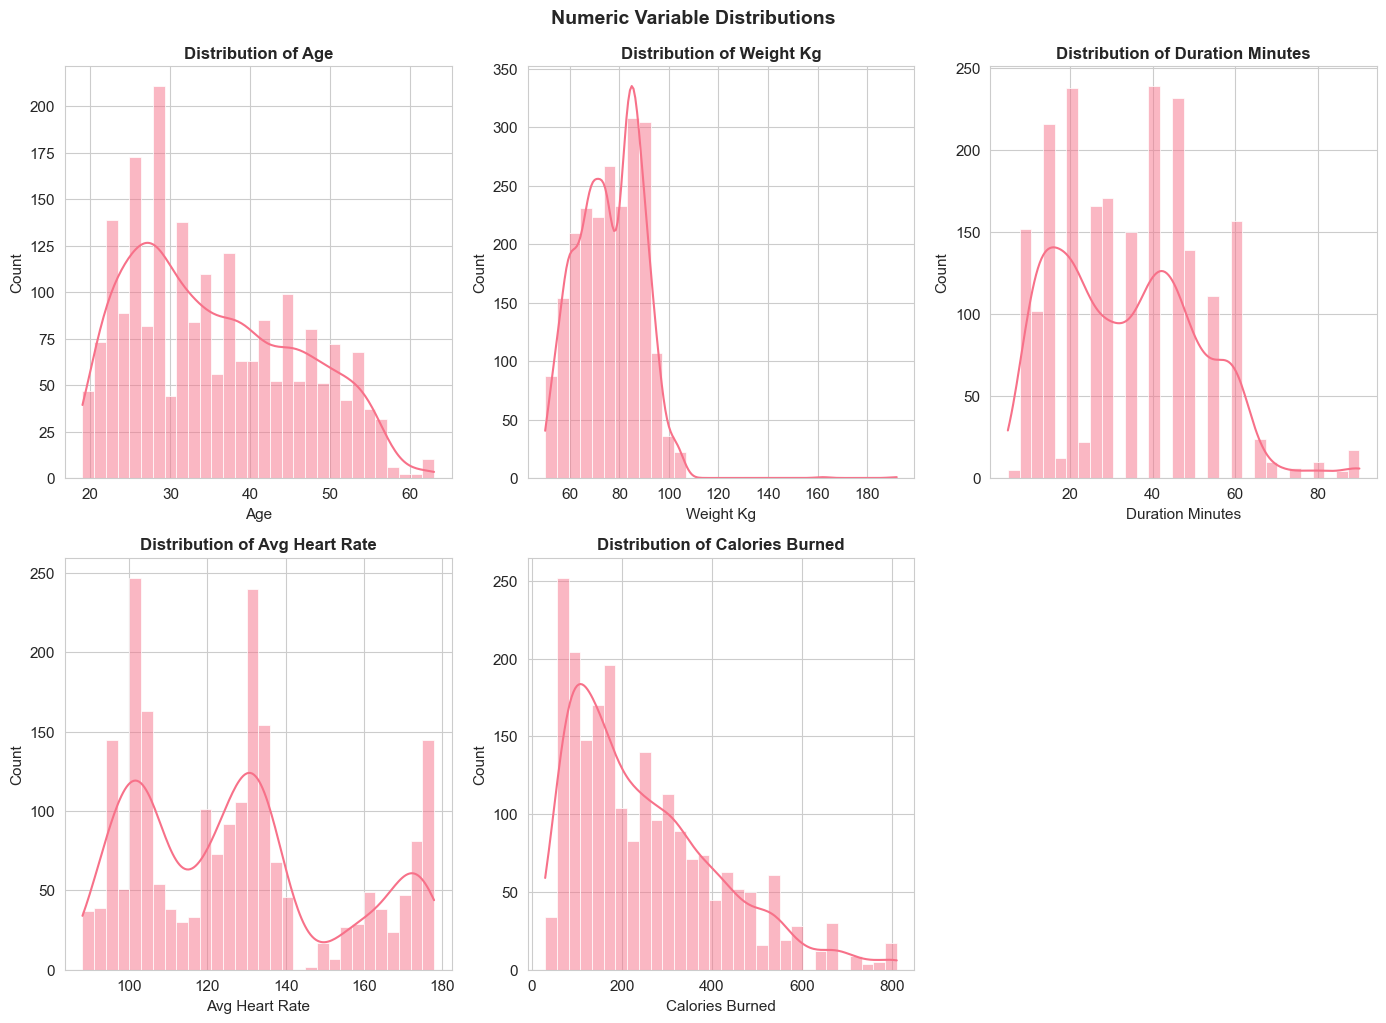

In [4]:
# Histograms for numeric columns
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

cols = ['age', 'weight_kg', 'duration_minutes', 'avg_heart_rate', 'calories_burned']
for i, col in enumerate(cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col.replace('_', ' ').title())

# Hide the 6th subplot (we only have 5 variables)
axes[5].set_visible(False)

plt.tight_layout()
plt.suptitle('Numeric Variable Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.show()

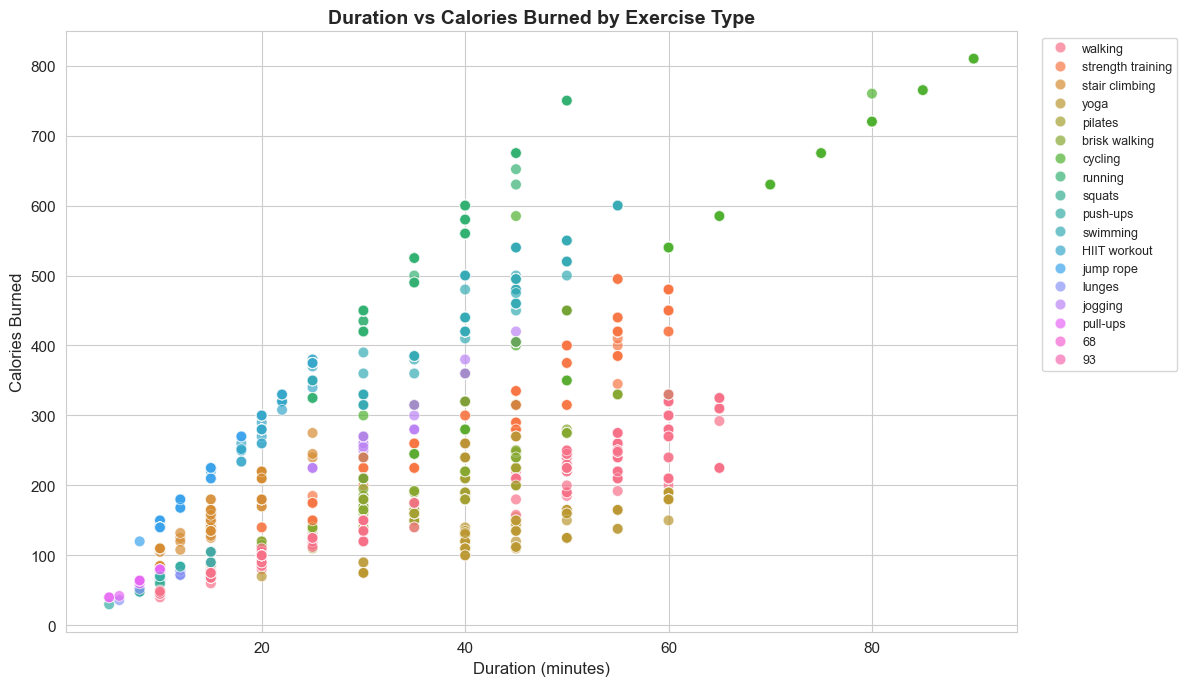

In [5]:
# Scatter: duration_minutes vs calories_burned, colored by exercise_type
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(data=df, x='duration_minutes', y='calories_burned', hue='exercise_type', 
                alpha=0.7, s=60, ax=ax, legend='brief')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Calories Burned', fontsize=12)
ax.set_title('Duration vs Calories Burned by Exercise Type', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

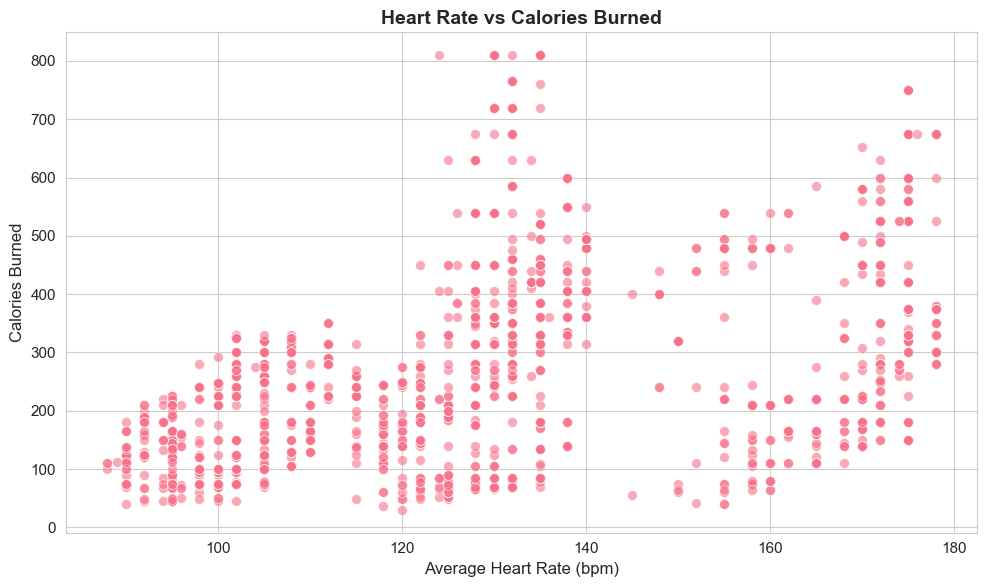

In [6]:
# Scatter: avg_heart_rate vs calories_burned
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_heart_rate', y='calories_burned', alpha=0.6, s=50)
ax.set_xlabel('Average Heart Rate (bpm)', fontsize=12)
ax.set_ylabel('Calories Burned', fontsize=12)
ax.set_title('Heart Rate vs Calories Burned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

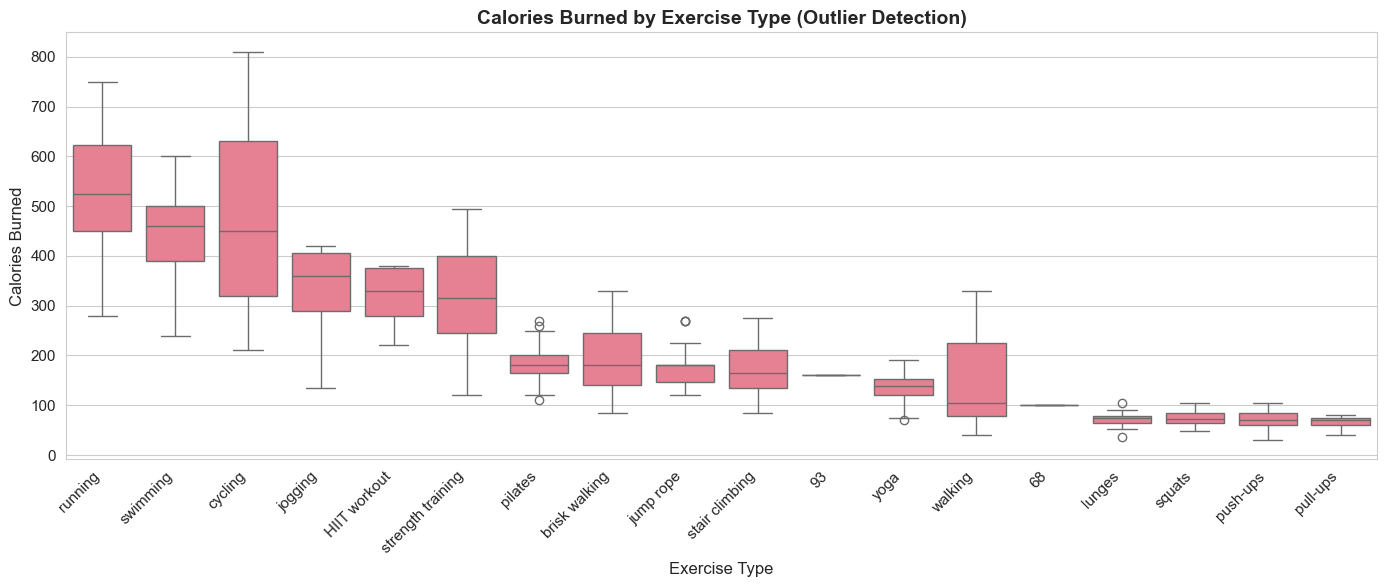

In [7]:
# Boxplots: calories_burned by exercise_type (spot unrealistic outliers)
fig, ax = plt.subplots(figsize=(14, 6))
order = df.groupby('exercise_type')['calories_burned'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='exercise_type', y='calories_burned', order=order)
ax.set_xlabel('Exercise Type', fontsize=12)
ax.set_ylabel('Calories Burned', fontsize=12)
ax.set_title('Calories Burned by Exercise Type (Outlier Detection)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()